# CSET343 — AI in Healthcare | Lab Assignment 3
Data acquisition, cleaning, preprocessing, EDA, and statistical analysis across
**Tabular, Textual, Image, and Signal** medical data modalities.

In [1]:
!pip -q install kagglehub wfdb nlpaug scikit-image opencv-python-headless statsmodels imagehash --no-warn-script-location

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
np.random.seed(42)

#save graphs
GRAPH_DIR = "/content/graphs"
os.makedirs(GRAPH_DIR, exist_ok=True)

def savefig(name):
    """Save the current figure into GRAPH_DIR before plt.show() clears it."""
    plt.savefig(os.path.join(GRAPH_DIR, f"{name}.png"), dpi=150, bbox_inches="tight")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 8.3 MB/s eta 0:00:00


---
## PART A — Tabular Data: Pima Indians Diabetes Dataset


In [2]:
# ---- A1. Acquire ----
import pandas as pd

cols = ["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin",
        "BMI","DiabetesPedigreeFunction","Age","Outcome"]

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
df = pd.read_csv(url, names=cols)

print(df.shape)
df.head()


(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# ---- A2. Inspect ----
df.info()
df.describe().T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


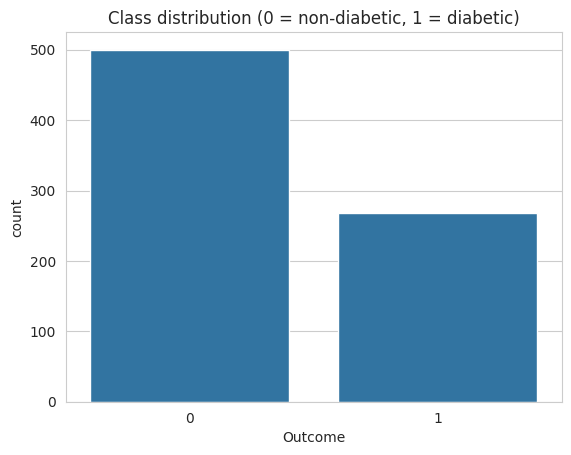

In [4]:
# Class balance check (healthcare data is very often imbalanced)
print(df["Outcome"].value_counts(normalize=True))
sns.countplot(x="Outcome", data=df)
plt.title("Class distribution (0 = non-diabetic, 1 = diabetic)")
savefig("A_class_distribution")
plt.show()


In [5]:
# ---- A3. Clean: implausible clinical values ----
zero_invalid_cols = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]

print("Zero counts (treated as missing):")
print((df[zero_invalid_cols] == 0).sum())

df_clean = df.copy()
df_clean[zero_invalid_cols] = df_clean[zero_invalid_cols].replace(0, np.nan)

print("\nMissingness % after flagging:")
print(df_clean[zero_invalid_cols].isna().mean().round(3) * 100)


Zero counts (treated as missing):
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Missingness % after flagging:
Glucose           0.7
BloodPressure     4.6
SkinThickness    29.6
Insulin          48.7
BMI               1.4
dtype: float64


In [6]:
# ---- A4. Impute ----
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(imputer.fit_transform(df_clean.drop(columns="Outcome")),
                           columns=df_clean.columns[:-1])
df_imputed["Outcome"] = df_clean["Outcome"].values
df_imputed.isna().sum()


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


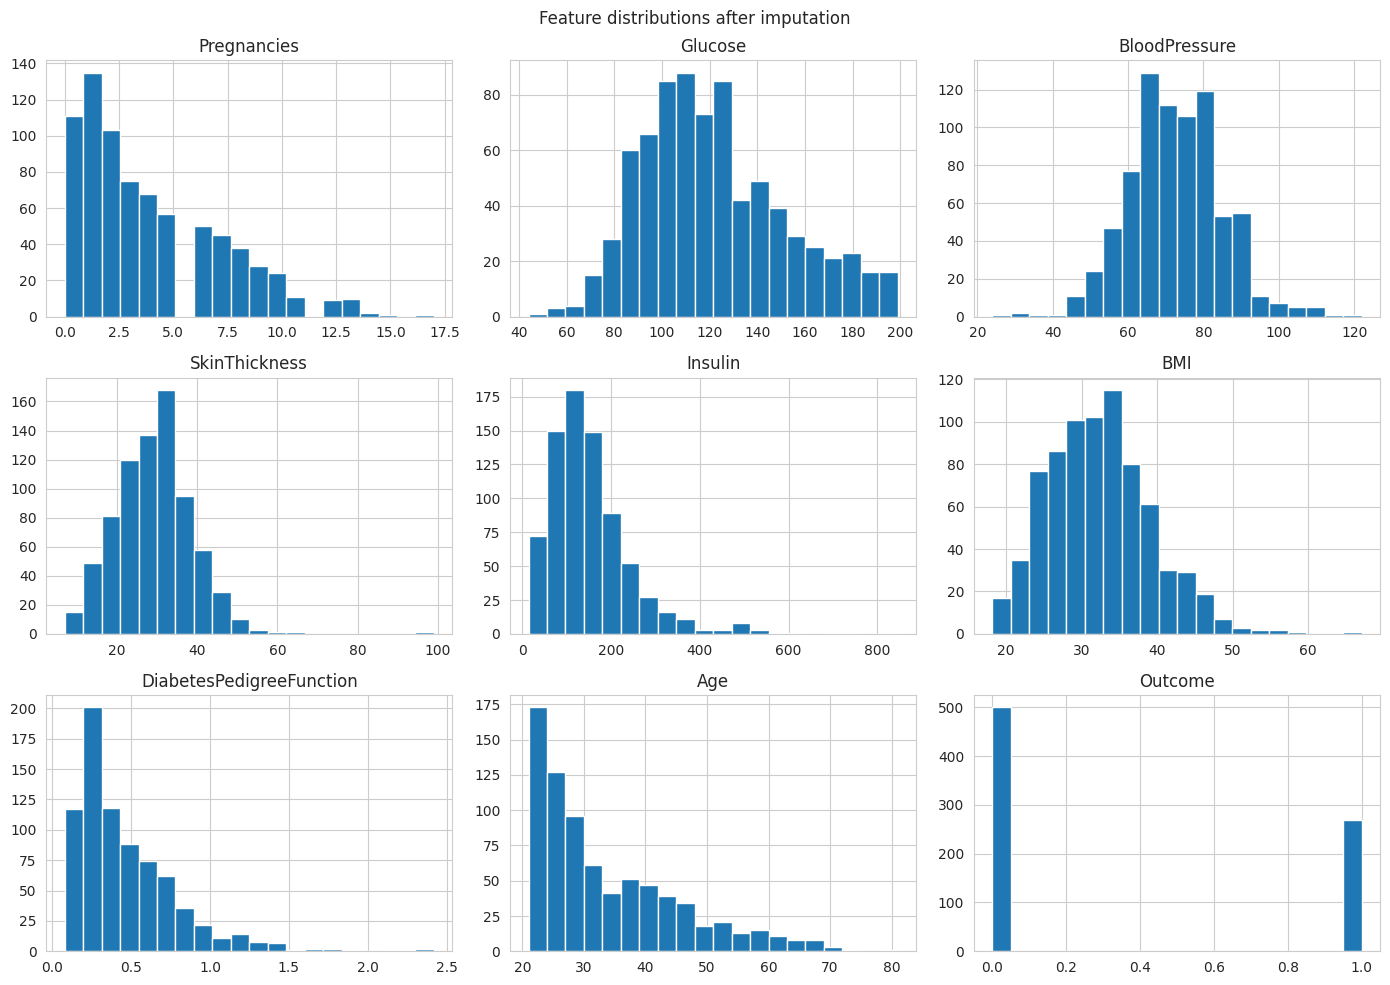

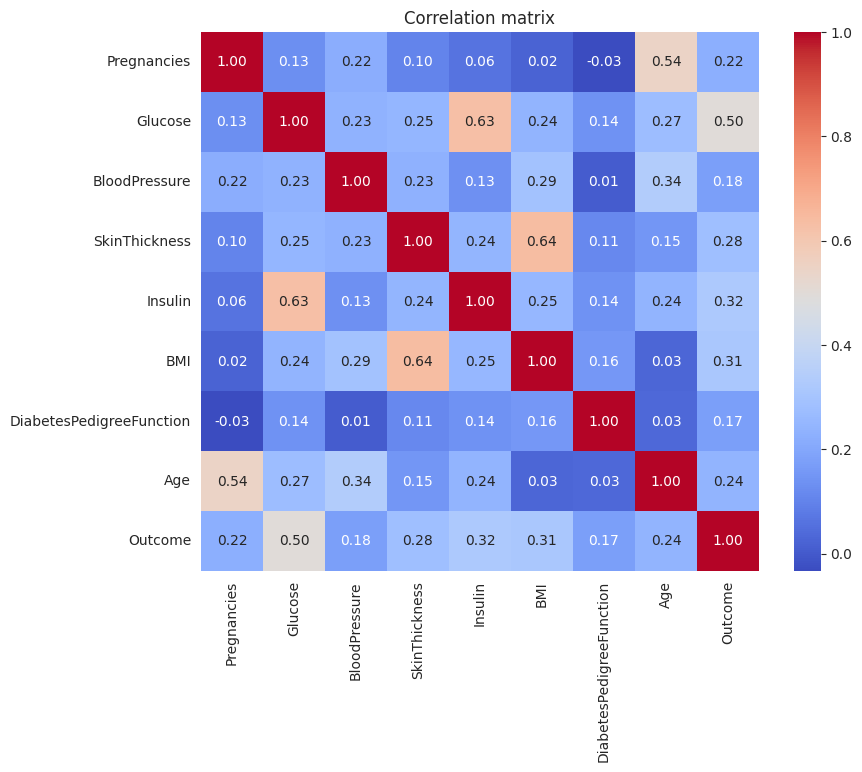

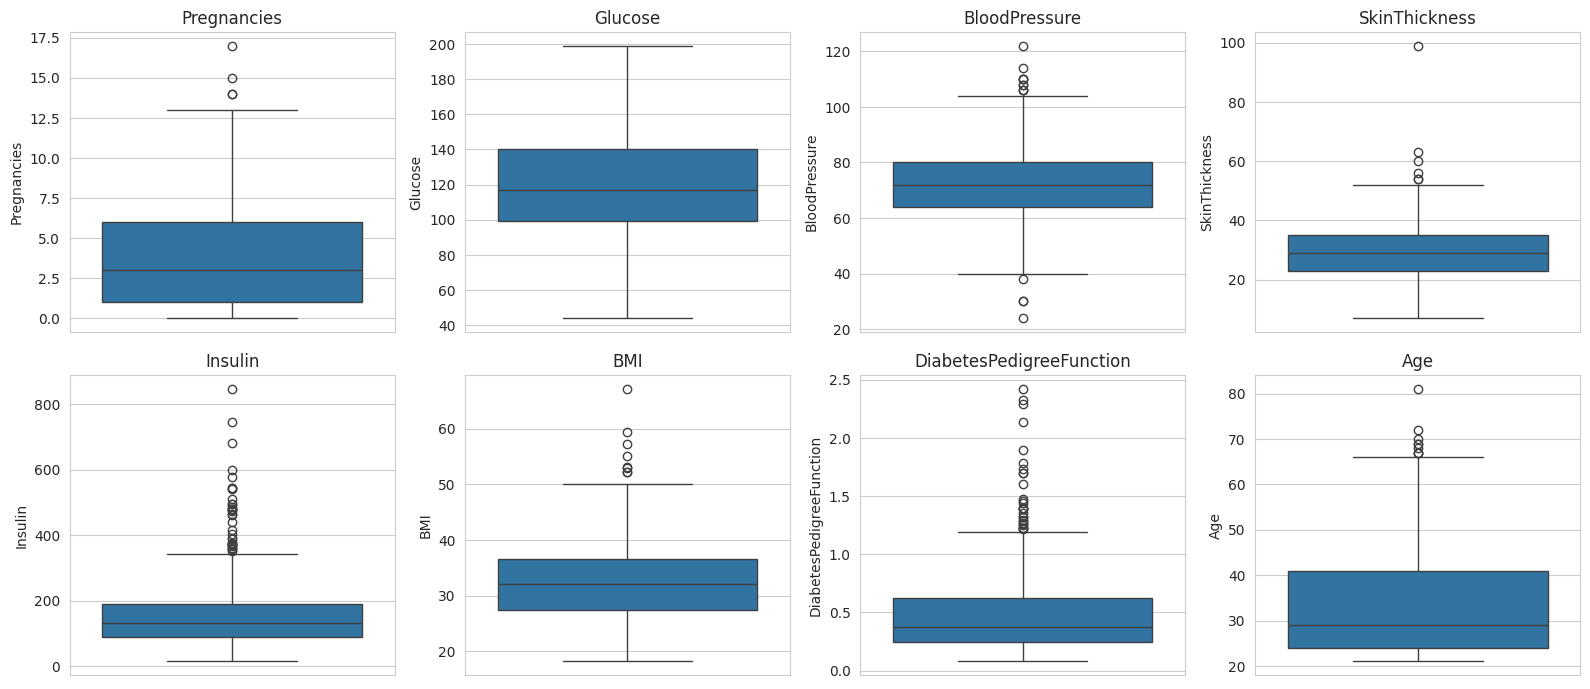

In [7]:
# ---- A5. EDA ----
df_imputed.hist(figsize=(14,10), bins=20)
plt.suptitle("Feature distributions after imputation")
plt.tight_layout()
savefig("A_feature_histograms")
plt.show()

plt.figure(figsize=(9,7))
sns.heatmap(df_imputed.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation matrix")
savefig("A_correlation_heatmap")
plt.show()

fig, axes = plt.subplots(2,4, figsize=(16,7))
for ax, c in zip(axes.flat, df_imputed.columns[:-1]):
    sns.boxplot(y=df_imputed[c], ax=ax)
    ax.set_title(c)
plt.tight_layout()
savefig("A_boxplots_outliers")
plt.show()


In [8]:
# ---- A6. Statistical tests ----
from scipy import stats

# (a) Hypothesis test: independent t-test
g0 = df_imputed.loc[df_imputed.Outcome==0, "Glucose"]
g1 = df_imputed.loc[df_imputed.Outcome==1, "Glucose"]
t_stat, p_val = stats.ttest_ind(g0, g1, equal_var=False)
print(f"T-test on Glucose vs Outcome: t={t_stat:.3f}, p={p_val:.5g}")
print("=> Reject H0 (significant difference)" if p_val < 0.05 else "=> Fail to reject H0")


T-test on Glucose vs Outcome: t=-14.992, p=8.1928e-42
=> Reject H0 (significant difference)


In [9]:
# (b) Chi-square test of independence
bmi_bins = [0, 18.5, 25, 30, 100]
bmi_labels = ["Underweight","Normal","Overweight","Obese"]
df_imputed["BMI_Category"] = pd.cut(df_imputed["BMI"], bins=bmi_bins, labels=bmi_labels)

contingency = pd.crosstab(df_imputed["BMI_Category"], df_imputed["Outcome"])
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)
print(contingency)
print(f"\nChi2={chi2:.3f}, dof={dof}, p={p_chi:.5g}")
print("=> BMI category and Outcome are dependent" if p_chi < 0.05 else "=> Independent")


Outcome         0    1
BMI_Category          
Underweight     4    0
Normal        101    7
Overweight    141   45
Obese         254  216

Chi2=75.216, dof=3, p=3.257e-16
=> BMI category and Outcome are dependent


In [10]:
# (c) One-way ANOVA
age_bins = [20,30,40,50,60,100]
age_labels = ["20-29","30-39","40-49","50-59","60+"]
df_imputed["AgeGroup"] = pd.cut(df_imputed["Age"], bins=age_bins, labels=age_labels)

groups = [grp["Glucose"].values for _, grp in df_imputed.groupby("AgeGroup")]
f_stat, p_anova = stats.f_oneway(*groups)
print(f"ANOVA F={f_stat:.3f}, p={p_anova:.5g}")
print("=> Glucose differs significantly across age groups" if p_anova < 0.05 else "=> No significant difference")


ANOVA F=15.225, p=5.5266e-12
=> Glucose differs significantly across age groups


In [11]:
# ---- A7. Feature engineering ----
df_imputed["Glucose_BMI_interaction"] = df_imputed["Glucose"] * df_imputed["BMI"]
df_imputed["Insulin_Glucose_ratio"] = df_imputed["Insulin"] / (df_imputed["Glucose"] + 1e-3)

# One-hot encode engineered categoricals
df_fe = pd.get_dummies(df_imputed, columns=["BMI_Category","AgeGroup"], drop_first=True)
df_fe.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Glucose_BMI_interaction,Insulin_Glucose_ratio,BMI_Category_Normal,BMI_Category_Overweight,BMI_Category_Obese,AgeGroup_30-39,AgeGroup_40-49,AgeGroup_50-59,AgeGroup_60+
0,6.0,148.0,72.0,35.0,169.0,33.6,0.627,50.0,1,4972.8,1.141884,False,False,True,False,True,False,False
1,1.0,85.0,66.0,29.0,58.6,26.6,0.351,31.0,0,2261.0,0.689404,False,True,False,True,False,False,False
2,8.0,183.0,64.0,25.8,164.6,23.3,0.672,32.0,1,4263.9,0.899449,True,False,False,True,False,False,False
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0,2500.9,1.056168,False,True,False,False,False,False,False
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1,5904.7,1.226268,False,False,True,True,False,False,False


In [12]:
# ---- A8. Feature selection ----
from sklearn.feature_selection import SelectKBest, f_classif

X = df_fe.drop(columns="Outcome")
y = df_fe["Outcome"]

selector = SelectKBest(score_func=f_classif, k=8)
selector.fit(X, y)
scores = pd.Series(selector.scores_, index=X.columns).sort_values(ascending=False)
print(scores)

top_features = scores.head(8).index.tolist()
print("\nSelected features:", top_features)


Glucose_BMI_interaction     286.003203
Glucose                     249.740848
Insulin                      86.840073
BMI                          83.418053
BMI_Category_Obese           71.107861
SkinThickness                64.377521
BMI_Category_Normal          47.295676
Age                          46.140611
Pregnancies                  39.670227
Insulin_Glucose_ratio        29.141563
AgeGroup_40-49               28.518808
BloodPressure                24.597655
DiabetesPedigreeFunction     23.871300
AgeGroup_30-39               16.150785
AgeGroup_50-59               13.144465
BMI_Category_Overweight      12.544227
AgeGroup_60+                  0.989757
dtype: float64

Selected features: ['Glucose_BMI_interaction', 'Glucose', 'Insulin', 'BMI', 'BMI_Category_Obese', 'SkinThickness', 'BMI_Category_Normal', 'Age']


In [13]:
# ---- A9. Scale into model-ready tensors ----
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch

X_train, X_test, y_train, y_test = train_test_split(
    X[top_features], y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

print(X_train_tensor.shape, y_train_tensor.shape)


torch.Size([614, 8]) torch.Size([614])


---
## PART B — Textual Data: MTSamples Medical Transcriptions


In [14]:
# ---- B1. Acquire ----
import kagglehub

# Dataset: tboyle10/medicaltranscriptions
path = kagglehub.dataset_download("tboyle10/medicaltranscriptions")
print("Downloaded to:", path)

import os
print(os.listdir(path))


text_df = pd.read_csv(os.path.join(path, "mtsamples.csv"))
print(text_df.shape)
text_df.head()


100%|██████████| 4.85M/4.85M [00:00<00:00, 43.9MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/tboyle10/medicaltranscriptions/versions/1
['mtsamples.csv']
(4999, 6)


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [15]:
# ---- B2. Inspect ----
text_df.info()
print("\nMissing values:\n", text_df.isna().sum())
print("\nUnique specialties:", text_df["medical_specialty"].nunique())
text_df["medical_specialty"].value_counts().head(15)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         4999 non-null   int64 
 1   description        4999 non-null   object
 2   medical_specialty  4999 non-null   object
 3   sample_name        4999 non-null   object
 4   transcription      4966 non-null   object
 5   keywords           3931 non-null   object
dtypes: int64(1), object(5)
memory usage: 234.5+ KB

Missing values:
 Unnamed: 0              0
description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64

Unique specialties: 40


,count
medical_specialty,
Surgery,1103
Consult - History and Phy.,516
Cardiovascular / Pulmonary,372
Orthopedic,355
Radiology,273
General Medicine,259
Gastroenterology,230
Neurology,223
SOAP / Chart / Progress Notes,166


In [16]:
# ---- B3. Clean ----
text_df_clean = text_df.dropna(subset=["transcription"]).drop_duplicates(subset=["transcription"]).copy()
text_df_clean = text_df_clean.drop(columns=[c for c in ["Unnamed: 0"] if c in text_df_clean.columns])

import re

def strip_phi(text):
    """Remove common PHI-like patterns: names after 'Dr./Mr./Mrs.', dates, ages,
    MRN/record numbers, phone numbers."""
    text = re.sub(r"\b(Dr|Mr|Mrs|Ms)\.?\s+[A-Z][a-z]+\b", "[NAME]", text)
    text = re.sub(r"\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b", "[DATE]", text)
    text = re.sub(r"\b\d{1,3}[- ]?(year|yo|y/o)[- ]?(old)?\b", "[AGE]", text, flags=re.I)
    text = re.sub(r"\bMRN[:#]?\s*\d+\b", "[MRN]", text, flags=re.I)
    text = re.sub(r"\b\d{3}[-.]?\d{3}[-.]?\d{4}\b", "[PHONE]", text)
    return text

text_df_clean["transcription_deid"] = text_df_clean["transcription"].astype(str).apply(strip_phi)
text_df_clean[["transcription","transcription_deid"]].head(2)


,transcription,transcription_deid
0,"SUBJECTIVE:, This 23-year-old white female pr...","SUBJECTIVE:, This [AGE] white female presents..."
1,"PAST MEDICAL HISTORY:, He has difficulty climb...","PAST MEDICAL HISTORY:, He has difficulty climb..."


In [17]:
# Remove noise: very short / near-empty transcriptions
text_df_clean["word_count"] = text_df_clean["transcription_deid"].str.split().apply(len)
print(text_df_clean["word_count"].describe())

text_df_clean = text_df_clean[text_df_clean["word_count"] >= 20].reset_index(drop=True)
print("Rows after noise removal:", len(text_df_clean))


count    2357.000000
mean      458.092915
std       315.055144
min         1.000000
25%       236.000000
50%       389.000000
75%       608.000000
max      2997.000000
Name: word_count, dtype: float64
Rows after noise removal: 2327


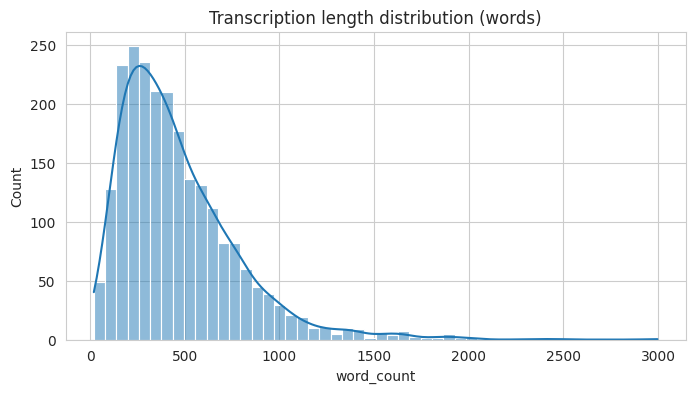

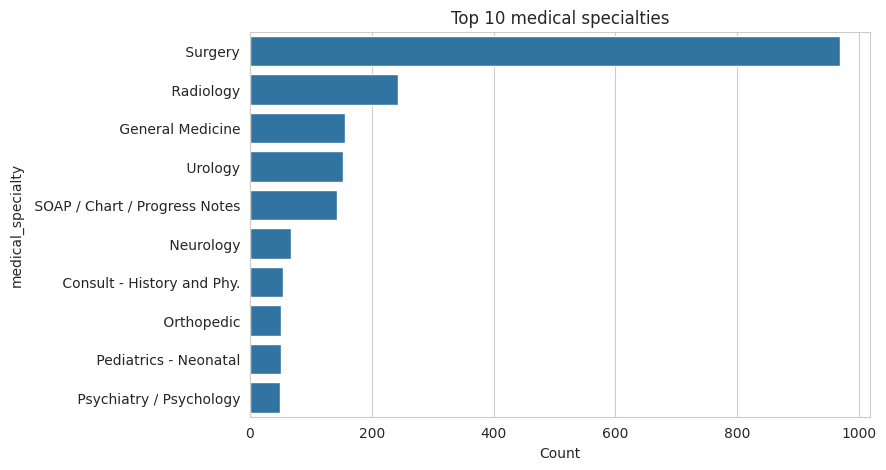

In [18]:
# ---- B4. EDA ----
plt.figure(figsize=(8,4))
sns.histplot(text_df_clean["word_count"], bins=50, kde=True)
plt.title("Transcription length distribution (words)")
savefig("B_wordcount_distribution")
plt.show()

top_specialties = text_df_clean["medical_specialty"].value_counts().head(10)
plt.figure(figsize=(8,5))
sns.barplot(x=top_specialties.values, y=top_specialties.index)
plt.title("Top 10 medical specialties")
plt.xlabel("Count")
savefig("B_top_specialties")
plt.show()


In [19]:
# ---- B5. Preprocess text ----
import nltk
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return tokens

text_df_clean["tokens"] = text_df_clean["transcription_deid"].apply(preprocess)
text_df_clean["clean_text"] = text_df_clean["tokens"].apply(lambda t: " ".join(t))
text_df_clean[["clean_text"]].head(2)


,clean_text
0,subjective age white female present complaint ...
1,past medical history difficulty climbing stair...


In [20]:
# ---- B6. Feature extraction: TF-IDF ----
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(text_df_clean["clean_text"])
print(X_tfidf.shape)

# ---- Alternative: token sequences for a transformer / RNN pipeline ----
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

keras_tok = Tokenizer(num_words=10000, oov_token="<OOV>")
keras_tok.fit_on_texts(text_df_clean["clean_text"])
sequences = keras_tok.texts_to_sequences(text_df_clean["clean_text"])
padded_sequences = pad_sequences(sequences, maxlen=200, padding="post", truncating="post")
print(padded_sequences.shape)


(2327, 3000)
(2327, 200)


In [23]:
import nlpaug.augmenter.word as naw
import nltk
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

syn_aug = naw.SynonymAug(aug_src="wordnet")

sample_text = text_df_clean["clean_text"].iloc[0]
augmented = syn_aug.augment(sample_text)
print("Original: ", sample_text[:200])
print("Augmented:", augmented[0][:200] if isinstance(augmented, list) else augmented[:200])

# Apply only to minority-class rows to fight class imbalance, e.g.:
minority_classes = top_specialties.index[-3:]
minority_rows = text_df_clean[text_df_clean["medical_specialty"].isin(minority_classes)]
print(f"\nAugmenting {len(minority_rows)} minority-class rows as an example (not run in full to save time).")

Original:  subjective age white female present complaint allergy used allergy lived seattle think worse past tried claritin zyrtec worked short time seemed lose effectiveness used allegra also used last summer b
Augmented: subjective age white female present ill allergy habituate allergy lived seattle think worse past tried claritin zyrtec worked short sentence seemed lose effectiveness used allegra also used last summe

Augmenting 153 minority-class rows as an example (not run in full to save time).


---
## PART C — Image Data: Chest X-Ray (Pneumonia) Dataset


In [24]:
# ---- C1. Acquire ----
import kagglehub, os

img_path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Downloaded to:", img_path)

# Typical structure: chest_xray/{train,test,val}/{NORMAL,PNEUMONIA}
for root, dirs, files in os.walk(img_path):
    depth = root[len(img_path):].count(os.sep)
    if depth <= 2:
        print(root, "->", len(files), "files")


Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Downloaded to: /kaggle/input/chest-xray-pneumonia
/kaggle/input/chest-xray-pneumonia -> 0 files
/kaggle/input/chest-xray-pneumonia/chest_xray -> 0 files
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray -> 1 files
/kaggle/input/chest-xray-pneumonia/chest_xray/__MACOSX -> 1 files
/kaggle/input/chest-xray-pneumonia/chest_xray/val -> 0 files
/kaggle/input/chest-xray-pneumonia/chest_xray/test -> 0 files
/kaggle/input/chest-xray-pneumonia/chest_xray/train -> 0 files


train/NORMAL       1341
train/PNEUMONIA    3875
test/NORMAL         234
test/PNEUMONIA      390
val/NORMAL            8
val/PNEUMONIA         8
dtype: int64


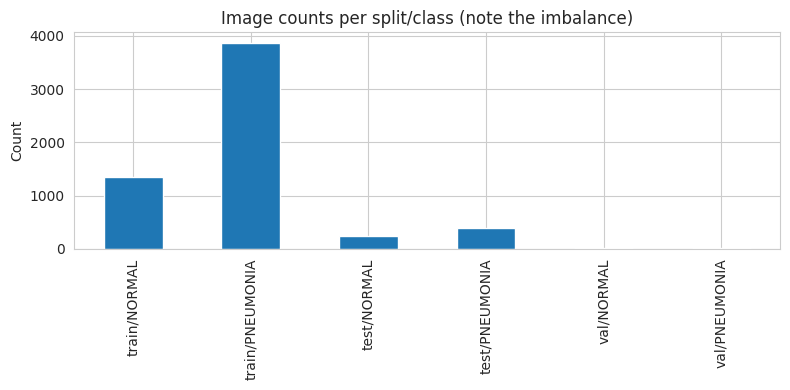

In [25]:
# ---- C2. Inspect: class balance ----
base = os.path.join(img_path, "chest_xray")
splits = ["train","test","val"]
classes = ["NORMAL","PNEUMONIA"]

counts = {}
for s in splits:
    for c in classes:
        d = os.path.join(base, s, c)
        counts[f"{s}/{c}"] = len(os.listdir(d)) if os.path.isdir(d) else 0

counts_df = pd.Series(counts)
print(counts_df)

plt.figure(figsize=(8,4))
counts_df.plot(kind="bar")
plt.title("Image counts per split/class (note the imbalance)")
plt.ylabel("Count")
plt.tight_layout()
savefig("C_class_split_counts")
plt.show()


In [26]:
# ---- C3. Clean: corrupt files + duplicate detection + metadata strip ----
from PIL import Image
import imagehash

def find_corrupt(folder):
    bad = []
    for f in os.listdir(folder):
        fp = os.path.join(folder, f)
        try:
            with Image.open(fp) as im:
                im.verify()
        except Exception:
            bad.append(fp)
    return bad

train_normal_dir = os.path.join(base, "train", "NORMAL")
bad_files = find_corrupt(train_normal_dir)
print(f"Corrupt files found in sample folder: {len(bad_files)}")

# Duplicate detection via perceptual hash (sample of first 200 for speed)
sample_files = os.listdir(train_normal_dir)[:200]
hashes = {}
dupes = []
for f in sample_files:
    fp = os.path.join(train_normal_dir, f)
    h = imagehash.phash(Image.open(fp))
    if h in hashes:
        dupes.append((hashes[h], f))
    else:
        hashes[h] = f
print(f"Duplicate-like pairs found in sample: {len(dupes)}")

# Metadata / EXIF anonymization: strip all metadata by re-saving pixel data only
def strip_metadata(img_path_in, img_path_out):
    img = Image.open(img_path_in)
    data = list(img.getdata())
    clean_img = Image.new(img.mode, img.size)
    clean_img.putdata(data)
    clean_img.save(img_path_out)

demo_out = "/content/demo_clean.png"
strip_metadata(os.path.join(train_normal_dir, sample_files[0]), demo_out)
print("Metadata-stripped copy saved to", demo_out)


Corrupt files found in sample folder: 0
Duplicate-like pairs found in sample: 0
Metadata-stripped copy saved to /content/demo_clean.png


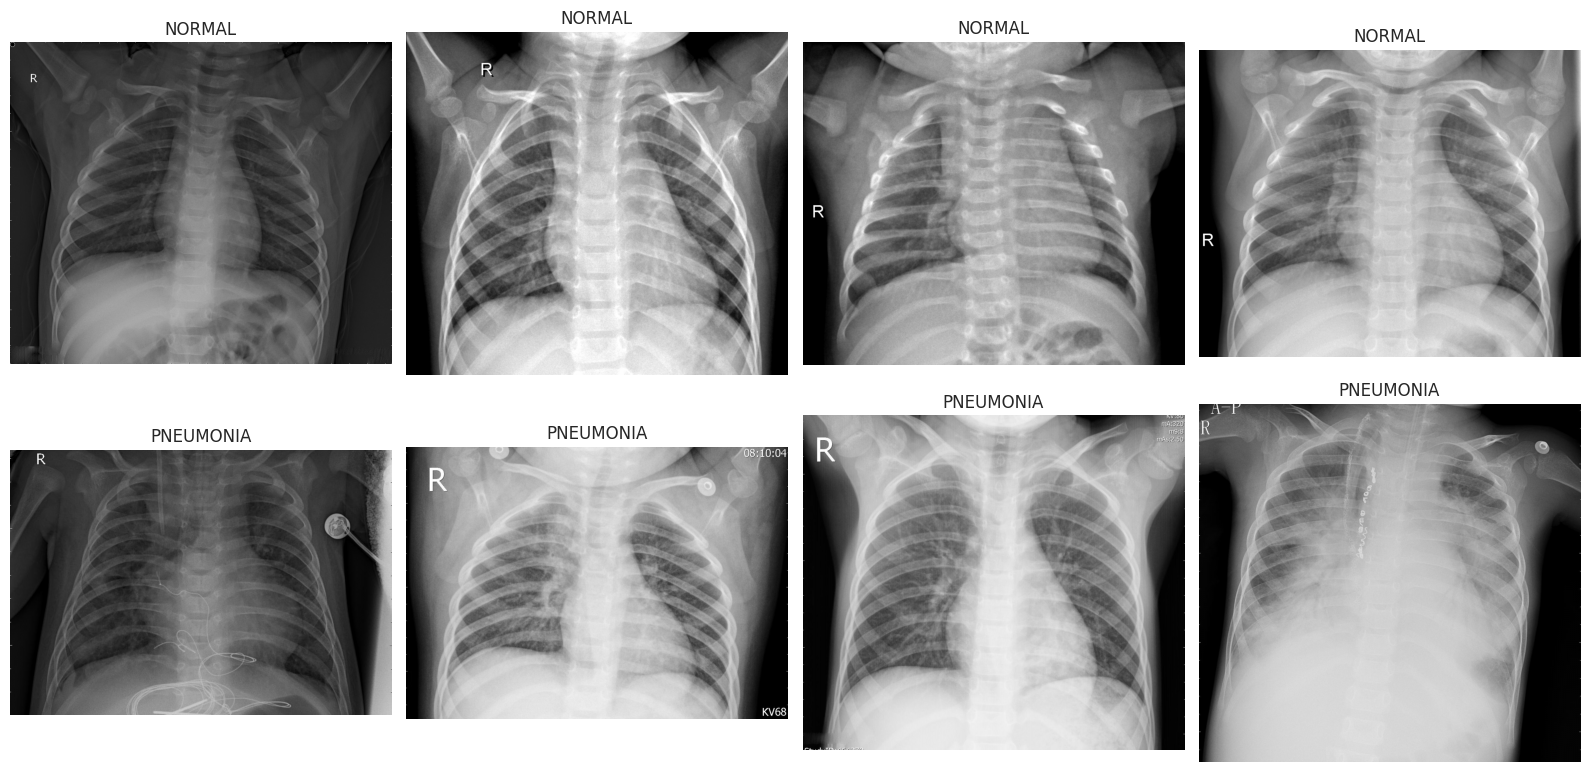

In [27]:
# ---- C4. EDA ----
fig, axes = plt.subplots(2,4, figsize=(16,8))
for i, cls in enumerate(classes):
    folder = os.path.join(base, "train", cls)
    files = os.listdir(folder)[:4]
    for j, f in enumerate(files):
        img = Image.open(os.path.join(folder, f))
        axes[i,j].imshow(img, cmap="gray")
        axes[i,j].set_title(cls)
        axes[i,j].axis("off")
plt.tight_layout()
savefig("C_sample_images")
plt.show()


             width       height
count   300.000000   300.000000
mean   1430.020000  1101.913333
std     357.794245   386.714372
min     428.000000   172.000000
25%    1150.000000   800.000000
50%    1409.000000  1074.500000
75%    1674.500000  1337.000000
max    2633.000000  2578.000000


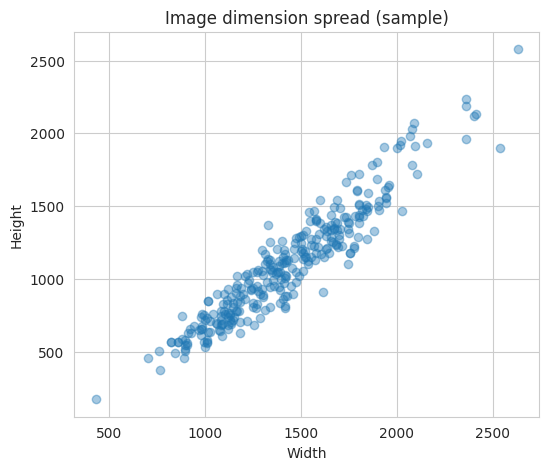

In [28]:
# Image size / aspect ratio distribution (sample)
sizes = []
for cls in classes:
    folder = os.path.join(base, "train", cls)
    for f in os.listdir(folder)[:150]:
        with Image.open(os.path.join(folder, f)) as im:
            sizes.append(im.size)

sizes_df = pd.DataFrame(sizes, columns=["width","height"])
print(sizes_df.describe())

plt.figure(figsize=(6,5))
plt.scatter(sizes_df["width"], sizes_df["height"], alpha=0.4)
plt.xlabel("Width"); plt.ylabel("Height")
plt.title("Image dimension spread (sample)")
savefig("C_dimension_spread")
plt.show()


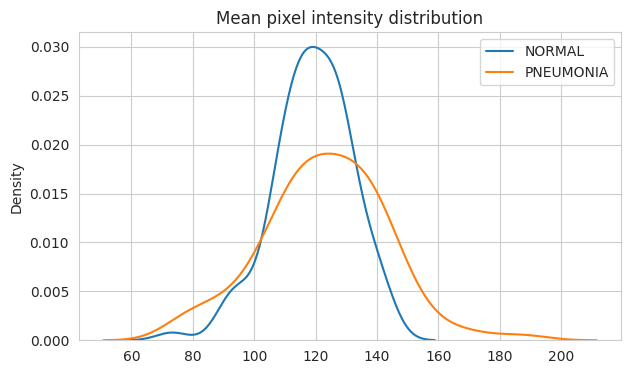

In [29]:
# Pixel intensity histogram (NORMAL vs PNEUMONIA, sample)
def mean_pixel_intensities(folder, n=100):
    vals = []
    for f in os.listdir(folder)[:n]:
        im = Image.open(os.path.join(folder, f)).convert("L")
        vals.append(np.array(im).mean())
    return vals

normal_intensity = mean_pixel_intensities(os.path.join(base,"train","NORMAL"))
pneumonia_intensity = mean_pixel_intensities(os.path.join(base,"train","PNEUMONIA"))

plt.figure(figsize=(7,4))
sns.kdeplot(normal_intensity, label="NORMAL")
sns.kdeplot(pneumonia_intensity, label="PNEUMONIA")
plt.title("Mean pixel intensity distribution")
plt.legend()
savefig("C_pixel_intensity_distribution")
plt.show()


In [30]:
# ---- C5. Preprocess into model-ready tensors + augmentation for minority class ----
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05,0.05), scale=(0.95,1.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

train_ds = datasets.ImageFolder(os.path.join(base,"train"), transform=train_transform)
test_ds  = datasets.ImageFolder(os.path.join(base,"test"),  transform=eval_transform)

print("Classes:", train_ds.class_to_idx)
print("Train size:", len(train_ds), "Test size:", len(test_ds))

# Class-balanced sampling to counter imbalance (WeightedRandomSampler)
targets = [t for _, t in train_ds.samples]
class_counts = np.bincount(targets)
class_weights = 1.0 / class_counts
sample_weights = [class_weights[t] for t in targets]

sampler = torch.utils.data.WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False)

imgs, labels = next(iter(train_loader))
print(imgs.shape, labels.shape)


Classes: {'NORMAL': 0, 'PNEUMONIA': 1}
Train size: 5216 Test size: 624
torch.Size([32, 3, 224, 224]) torch.Size([32])


---
## PART D — Signal Data: MIT-BIH Arrhythmia Database (ECG)


In [31]:
# ---- D1. Acquire ----
import wfdb, os

DATA_DIR = "/content/mitdb"
os.makedirs(DATA_DIR, exist_ok=True)

# Download a handful of records directly from PhysioNet (full DB is 48 records)
record_ids = ["100","101","102"]
wfdb.dl_database("mitdb", dl_dir=DATA_DIR, records=record_ids)
print(os.listdir(DATA_DIR))


Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating list of all files for: 100
Generating list of all files for: 101
Generating list of all files for: 102
Finished downloading files
['101.hea', '102.dat', '102.atr', '101.atr', '100.hea', '100.atr', '102.hea', '100.dat', '101.dat']


In [32]:
# ---- D2. Inspect ----
record = wfdb.rdrecord(os.path.join(DATA_DIR, "100"))
annotation = wfdb.rdann(os.path.join(DATA_DIR, "100"), "atr")

print("Sampling frequency:", record.fs)
print("Signal shape:", record.p_signal.shape)
print("Lead names:", record.sig_name)
print("Number of annotated beats:", len(annotation.sample))
print("Beat symbol distribution:")
print(pd.Series(annotation.symbol).value_counts())


Sampling frequency: 360
Signal shape: (650000, 2)
Lead names: ['MLII', 'V5']
Number of annotated beats: 2274
Beat symbol distribution:
N    2239
A      33
+       1
V       1
Name: count, dtype: int64


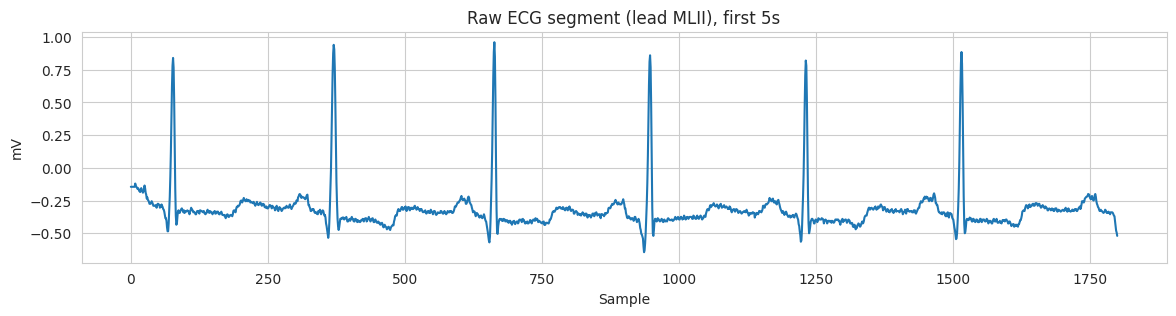

In [33]:
# ---- D3. EDA: plot a raw signal segment ----
fs = record.fs
segment = record.p_signal[:fs*5, 0]  # first 5 seconds, lead 0

plt.figure(figsize=(14,3))
plt.plot(segment)
plt.title(f"Raw ECG segment (lead {record.sig_name[0]}), first 5s")
plt.xlabel("Sample")
plt.ylabel("mV")
savefig("D_raw_ecg_segment")
plt.show()


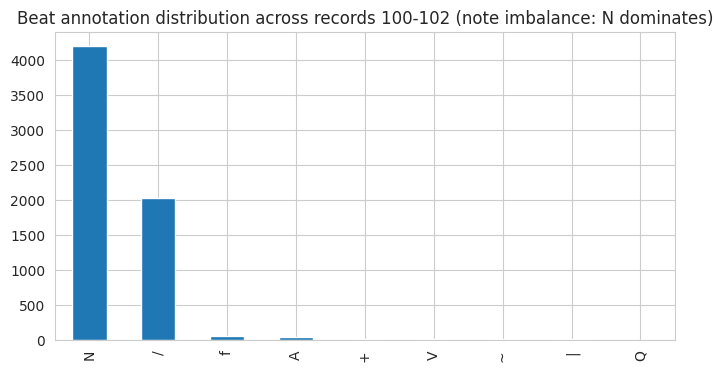

In [34]:
# Beat-type distribution across the loaded records
all_symbols = []
for rid in record_ids:
    ann = wfdb.rdann(os.path.join(DATA_DIR, rid), "atr")
    all_symbols.extend(ann.symbol)

sym_counts = pd.Series(all_symbols).value_counts()
plt.figure(figsize=(8,4))
sym_counts.plot(kind="bar")
plt.title("Beat annotation distribution across records 100-102 (note imbalance: N dominates)")
savefig("D_beat_annotation_distribution")
plt.show()


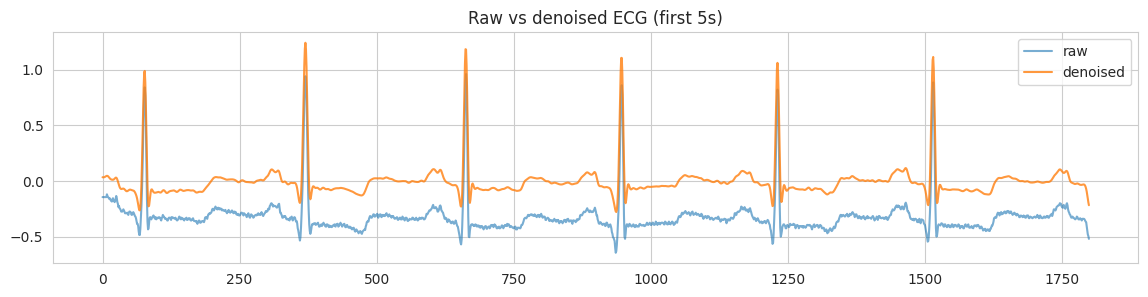

In [35]:
# ---- D4. Clean / denoise ----
from scipy.signal import butter, filtfilt, iirnotch

def bandpass_filter(sig, fs, low=0.5, high=40, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype="band")
    return filtfilt(b, a, sig)

def notch_filter(sig, fs, freq=60, q=30):
    b, a = iirnotch(freq/(fs/2), q)
    return filtfilt(b, a, sig)

raw_sig = record.p_signal[:, 0]
denoised = bandpass_filter(raw_sig, fs)      # remove baseline wander + high-freq noise
denoised = notch_filter(denoised, fs)        # remove powerline interference

plt.figure(figsize=(14,3))
plt.plot(raw_sig[:fs*5], label="raw", alpha=0.6)
plt.plot(denoised[:fs*5], label="denoised", alpha=0.8)
plt.legend()
plt.title("Raw vs denoised ECG (first 5s)")
savefig("D_raw_vs_denoised_ecg")
plt.show()


In [36]:
# Flag flatline / saturated segments (sensor fault, not real cardiac signal)
window = fs * 2  # 2-second windows
flat_windows = []
for start in range(0, len(denoised) - window, window):
    seg = denoised[start:start+window]
    if seg.std() < 1e-4:
        flat_windows.append(start)
print(f"Flatline/saturated windows detected: {len(flat_windows)}")


Flatline/saturated windows detected: 0


In [37]:
# ---- D5. Preprocess: normalize + segment into beat-centered windows ----
from sklearn.preprocessing import StandardScaler

denoised_norm = StandardScaler().fit_transform(denoised.reshape(-1,1)).flatten()

# Build fixed-length windows centered on each annotated R-peak
half_win = int(0.28 * fs)  # ~280ms each side
X_windows, y_windows = [], []

for sample_idx, sym in zip(annotation.sample, annotation.symbol):
    start, end = sample_idx - half_win, sample_idx + half_win
    if start < 0 or end > len(denoised_norm):
        continue
    X_windows.append(denoised_norm[start:end])
    y_windows.append(sym)

X_windows = np.array(X_windows)
y_windows = np.array(y_windows)
print("Windowed signal tensor shape:", X_windows.shape)
print("Label distribution:\n", pd.Series(y_windows).value_counts())


Windowed signal tensor shape: (2271, 200)
Label distribution:
 N    2237
A      33
V       1
Name: count, dtype: int64


In [38]:
# ---- D6. Feature engineering (handcrafted, alongside raw-window tensors) ----
def extract_features(window):
    return {
        "mean": window.mean(),
        "std": window.std(),
        "min": window.min(),
        "max": window.max(),
        "range": window.max() - window.min(),
        "energy": np.sum(window**2),
    }

feat_df = pd.DataFrame([extract_features(w) for w in X_windows])
feat_df["label"] = y_windows
feat_df.head()


,mean,std,min,max,range,energy,label
0,0.062101,1.201885,-1.078225,6.779370,7.857595,289.676778,N
1,0.023389,1.090801,-1.258048,6.464935,7.722983,238.078665,N
2,-0.024396,1.035420,-1.523160,6.037157,7.560317,214.537962,N
3,-0.034115,0.975356,-1.232018,5.794155,7.026173,190.496713,N
4,-0.005081,1.044589,-1.188694,6.082052,7.270746,218.238470,N


In [39]:
# ---- D7. Model-ready tensors ----
import torch

# Keep the top-N most frequent beat classes to avoid a 1-sample class breaking stratified split
top_classes = pd.Series(y_windows).value_counts().head(5).index.tolist()
mask = np.isin(y_windows, top_classes)

X_final = X_windows[mask]
y_final = y_windows[mask]

label_map = {c: i for i, c in enumerate(top_classes)}
y_encoded = np.array([label_map[l] for l in y_final])

X_tensor = torch.tensor(X_final, dtype=torch.float32).unsqueeze(1)  # (N, 1, window_len)
y_tensor = torch.tensor(y_encoded, dtype=torch.long)

print(X_tensor.shape, y_tensor.shape)
print("Classes kept:", label_map)


torch.Size([2271, 1, 200]) torch.Size([2271])
Classes kept: {'N': 0, 'A': 1, 'V': 2}


In [40]:
import shutil
from google.colab import files

zip_path = shutil.make_archive("/content/all_graphs", "zip", GRAPH_DIR)
print("Saved graphs:", os.listdir(GRAPH_DIR))
print("Zip created at:", zip_path)

files.download(zip_path)


Saved graphs: ['D_beat_annotation_distribution.png', 'A_class_distribution.png', 'C_sample_images.png', 'B_wordcount_distribution.png', 'A_boxplots_outliers.png', 'D_raw_vs_denoised_ecg.png', 'A_correlation_heatmap.png', 'C_pixel_intensity_distribution.png', 'C_dimension_spread.png', 'C_class_split_counts.png', 'B_top_specialties.png', 'D_raw_ecg_segment.png', 'A_feature_histograms.png']
Zip created at: /content/all_graphs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>